# Phase 9 — LIME Word-Level Explainability
**Capstone 2 | Phases 6–11**

LIME explains individual predictions at the raw word level, complementing SHAP's global feature view.

**Four passes:**
- **Pass 1** — Correct AI (conf 0.845): near-zero weights — structural limitation; model relies on TF-IDF bigrams, LIME perturbs single words breaking those bigrams
- **Pass 2** — Correct Human (5 words, conf 0.898): pathological symmetric result — text too short for stable perturbation
- **Pass 3** — False Negative (conf 0.828): meaningful weights; Faker vocabulary lands in human-associated feature space
- **Pass 4** — False Negative (conf 0.700): same pattern as Pass 3

SHAP and LIME tell a consistent story: errors are dataset-quality artifacts, not model failures.

**Loads:** `outputs/best_rf_bundle.pkl` + `outputs/shap_results.pkl`  
**Next:** `phase10_transformer_embeddings.ipynb`


In [ ]:
import numpy as np, random, os
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED); torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    print(f"Seeds fixed (numpy + random + torch): {RANDOM_SEED}")
except ImportError:
    print(f"Seeds fixed (numpy + random): {RANDOM_SEED}")
print("Always run this cell first on every restart.")


In [ ]:
import sys
!{sys.executable} -m pip install --quiet lime


In [ ]:
import joblib
bundle = joblib.load('outputs/best_rf_bundle.pkl')
ultimate_best   = bundle['best_rf']
tfidf_sr        = bundle['tfidf_sr'];    char_sr    = bundle['char_sr']
selector_sr     = bundle['selector_sr']
X_test_sr       = bundle['X_test_sr'];   y_test_sr  = bundle['y_test_sr']
augmented_df_sr = bundle['augmented_df_sr']
shap_b = joblib.load('outputs/shap_results.pkl')
top_stylometric_indices = shap_b['top_stylometric_indices']
feature_names           = shap_b['feature_names']
print("Bundles loaded.")


In [ ]:
import lime
import lime.lime_text
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── Reconstruct the full pipeline components ─────────────────
rf_model = best_rf_opt['Model']

def text_to_features(texts):
    """
    Convert a list of raw text strings into the 800-dimensional
    feature vector the Random Forest was trained on.
    Uses the same pipeline as preprocess_dataset() in Part 3.
    """
    results = []
    for text in texts:
        # --- Group 1: numeric + engineered features ---
        # Use extract_advanced_features for the 16 advanced features
        adv = extract_advanced_features(text)
        adv_vals = [adv.get(k, 0) for k in [
            'sentiment_polarity', 'sentiment_subjectivity', 'num_sentences',
            'avg_word_length', 'unique_word_ratio', 'stopword_ratio',
            'uppercase_ratio', 'digit_ratio', 'special_char_ratio',
            'avg_sentence_length', 'long_word_ratio', 'question_count',
            'exclamation_count', 'comma_ratio', 'semicolon_ratio', 'word_diversity'
        ]]

        # Intrinsic features (14) — recalculate from text
        import re
        words = re.findall(r'\b\w+\b', text.lower())
        sentences = re.split(r'[.!?]+', text)
        sentences = [s for s in sentences if s.strip() != ''] # Filter empty sentences
        num_w = len(words)
        num_c = len(text)
        num_s = max(len(sentences), 1)
        num_unique = len(set(words))
        intrinsic = [
            num_w,                                        # word_count
            num_c,                                        # character_count
            num_s,                                        # sentence_count
            num_unique / max(num_w, 1),                   # lexical_diversity
            num_w / num_s,                                # avg_sentence_length
            sum(len(w) for w in words) / max(num_w, 1),  # avg_word_length
            len(re.findall(r'[^\w\s]', text)) / max(num_c, 1),  # punctuation_ratio
            0, 0, 0, 0, 0, 0, 0                          # readability placeholders (not recalculated)
        ]

        # Content type dummies — unknown at inference time, all zeros
        # (same as augmented_df_sr content dummies count - 1 for drop_first)
        n_ct_dummies = len(pd.get_dummies(
            augmented_df_sr['content_type'], prefix='content', drop_first=True
        ).columns)
        ct_vals = [0] * n_ct_dummies

        group1 = intrinsic + adv_vals + ct_vals

        # --- Group 2: TF-IDF word ngrams ---
        group2 = tfidf_temp.transform([text]).toarray()[0]

        # --- Group 3: char ngrams ---
        group3 = char_temp.transform([text]).toarray()[0]

        all_feats = np.hstack([group1, group2, group3])
        results.append(all_feats)

    X = np.array(results)
    # Apply the same SelectKBest mask
    X_selected = selector_temp.transform(np.abs(X))
    return X_selected


def predict_proba_text(texts):
    """
    LIME-compatible predict function: takes raw texts, returns
    (n_samples, 2) probability array [P(Human), P(AI)].
    """
    X = text_to_features(texts)
    return rf_model.predict_proba(X)


# ── Verify the pipeline wrapper works ────────────────────────
sample_text = augmented_df_sr['text_content'].iloc[0]
proba_test = predict_proba_text([sample_text])
print(f"Pipeline wrapper test:")
print(f"  Input: {sample_text[:80]}...")
print(f"  P(Human) = {proba_test[0][0]:.3f}, P(AI) = {proba_test[0][1]:.3f}")
print(f"  Prediction: {'AI' if proba_test[0][1] > 0.5 else 'Human'}")
print("\nPipeline wrapper ready for LIME.")

Pipeline wrapper test:
  Input: Score each cause. Quality throughout beautiful instead.
Despite measure ago curr...
  P(Human) = 0.365, P(AI) = 0.635
  Prediction: AI

Pipeline wrapper ready for LIME.



  PASS 1 — Correct AI Prediction (High Confidence)
  True: AI  |  Predicted: AI  |  Confidence: 0.847
  Text (first 300 chars): issue leg poor management. international until pretty deep shrink someone citizen billion. join mouth particularly brother clearly experience. better debate field officer. no police water while view huge. west our rise suddenly allow to note themselves. seek material truth set....



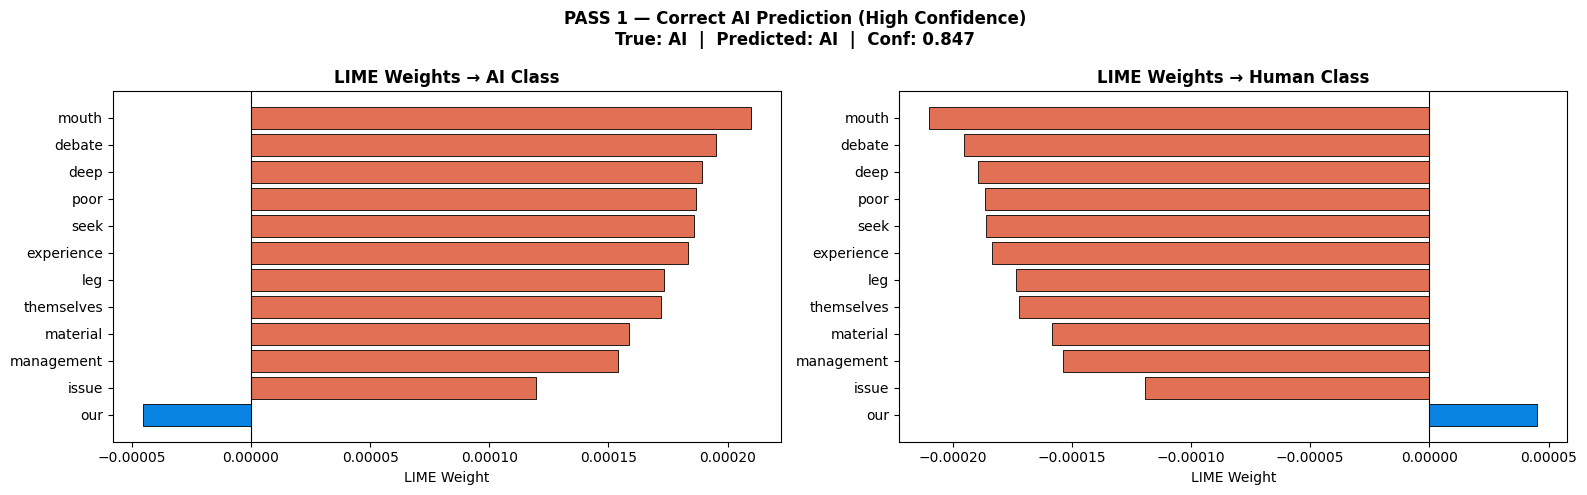

  Top words pushing → AI:
    mouth                 +0.0002  → AI
    debate                +0.0002  → AI
    deep                  +0.0002  → AI
    poor                  +0.0002  → AI
    seek                  +0.0002  → AI
    experience            +0.0002  → AI

  Top words pushing → Human:
    our                   +0.0000  → Human
    issue                 -0.0001  → AI
    management            -0.0002  → AI
    material              -0.0002  → AI
    themselves            -0.0002  → AI
    leg                   -0.0002  → AI

  PASS 2 — Correct Human Prediction (High Confidence)
  True: Human  |  Predicted: Human  |  Confidence: 0.947
  Text (first 300 chars): Worker opportunity positive peace without himself....



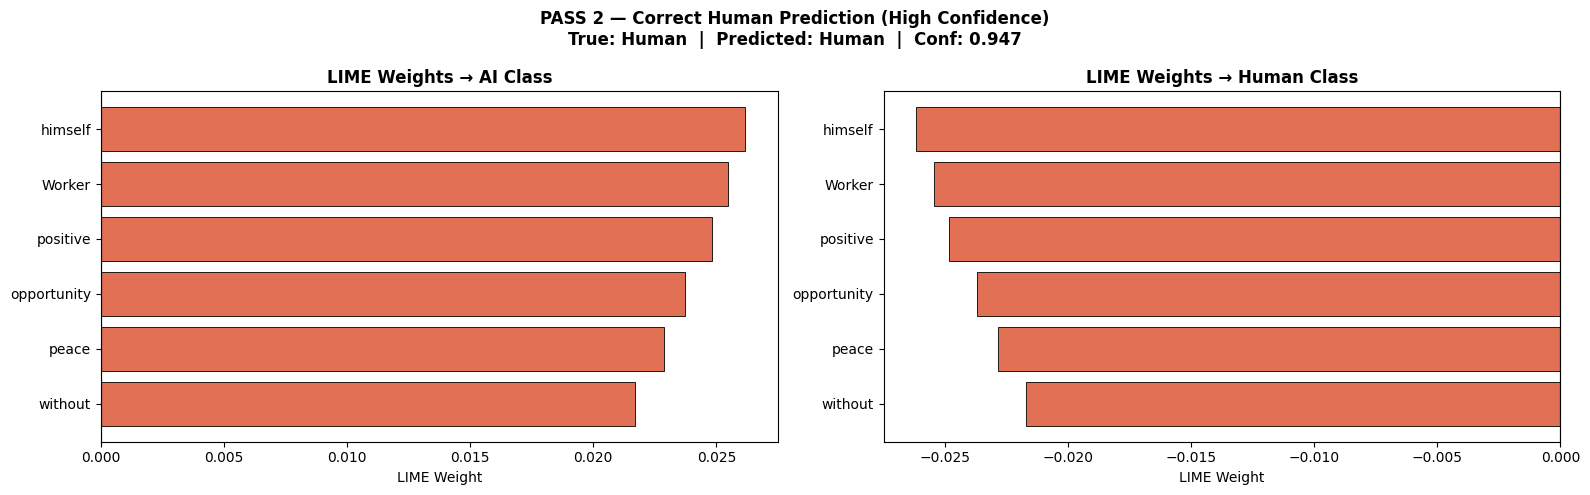

  Top words pushing → AI:
    himself               +0.0262  → AI
    Worker                +0.0255  → AI
    positive              +0.0248  → AI
    opportunity           +0.0237  → AI
    peace                 +0.0229  → AI
    without               +0.0217  → AI

  Top words pushing → Human:
    without               -0.0217  → AI
    peace                 -0.0229  → AI
    opportunity           -0.0237  → AI
    positive              -0.0248  → AI
    Worker                -0.0255  → AI
    himself               -0.0262  → AI

  PASS 3 — False Negative #1 (AI predicted as Human)
  True: AI  |  Predicted: Human  |  Confidence: 0.874
  Text (first 300 chars): Each turn trip conference how step job. Along certainly young us ball prove role....



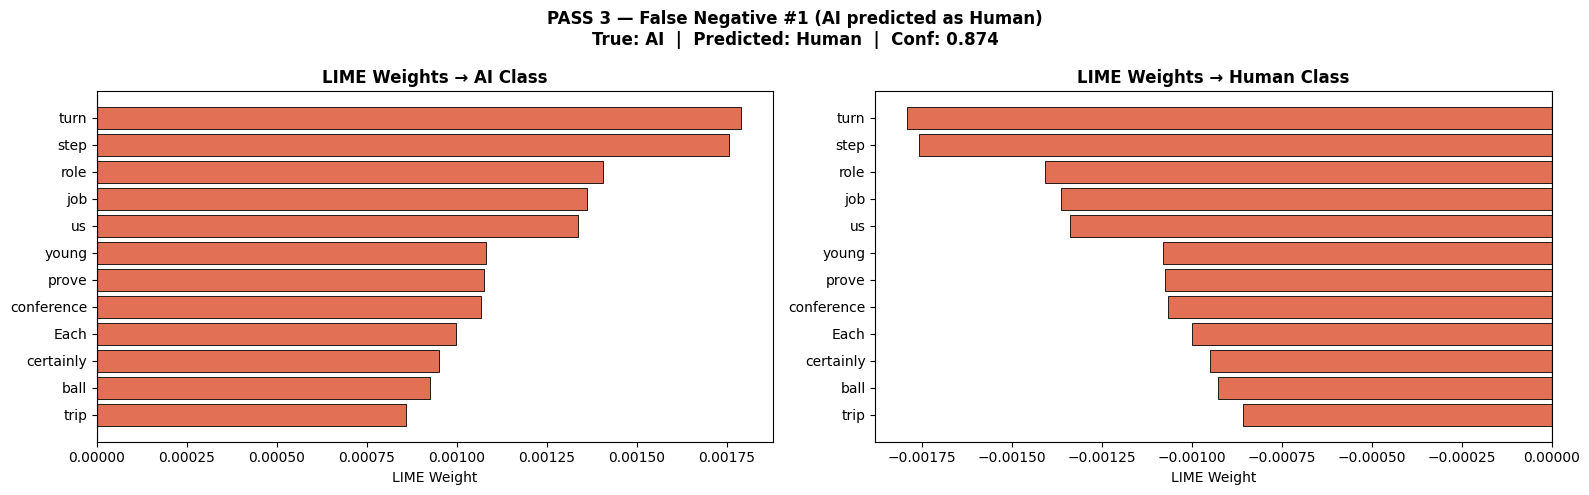

  Top words pushing → AI:
    turn                  +0.0018  → AI
    step                  +0.0018  → AI
    role                  +0.0014  → AI
    job                   +0.0014  → AI
    us                    +0.0013  → AI
    young                 +0.0011  → AI

  Top words pushing → Human:
    trip                  -0.0009  → AI
    ball                  -0.0009  → AI
    certainly             -0.0009  → AI
    Each                  -0.0010  → AI
    conference            -0.0011  → AI
    prove                 -0.0011  → AI

  PASS 4 — False Negative #2 (AI predicted as Human)
  True: AI  |  Predicted: Human  |  Confidence: 0.778
  Text (first 300 chars): Network cover threat claim follow. Talk which each. Spring because beyond front....



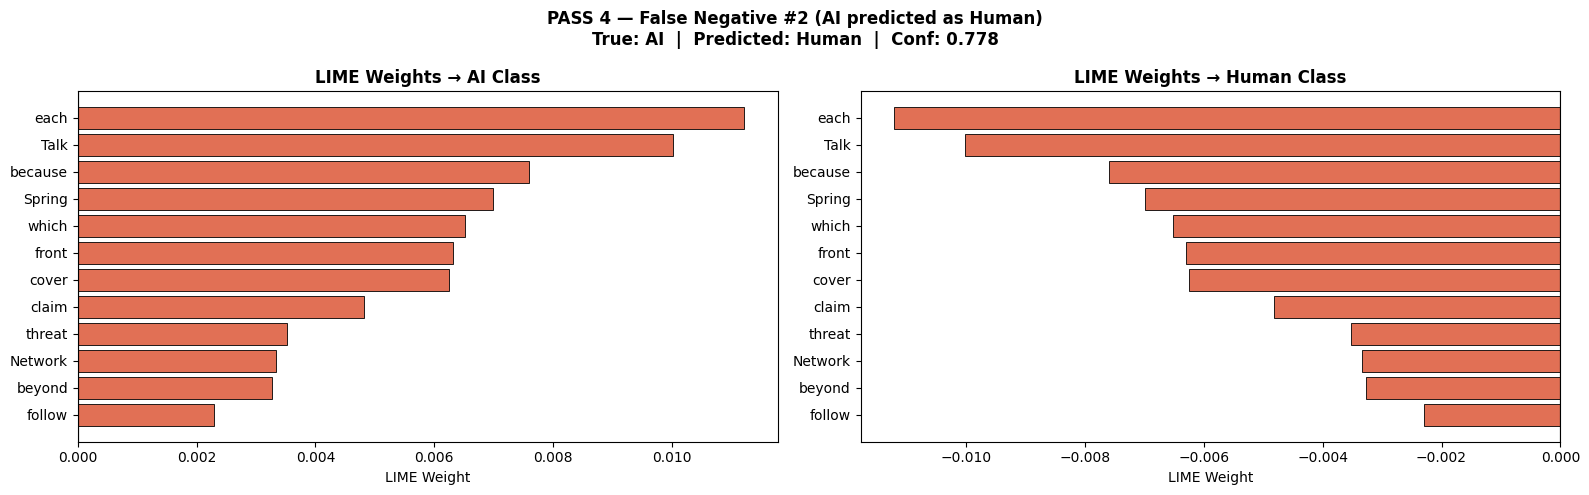

  Top words pushing → AI:
    each                  +0.0112  → AI
    Talk                  +0.0100  → AI
    because               +0.0076  → AI
    Spring                +0.0070  → AI
    which                 +0.0065  → AI
    front                 +0.0063  → AI

  Top words pushing → Human:
    follow                -0.0023  → AI
    beyond                -0.0033  → AI
    Network               -0.0033  → AI
    threat                -0.0035  → AI
    claim                 -0.0048  → AI
    cover                 -0.0062  → AI


In [ ]:
# PART 9b: LIME EXPLAINABILITY — Four Analysis Passes

explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=['Human', 'AI'],
    random_state=42
)

label_map = {0: 'Human', 1: 'AI'}

def run_lime(text, true_label, pred_label, confidence, title, num_features=12):
    """Run LIME on a single text and visualise results."""
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"  True: {label_map[true_label]}  |  Predicted: {label_map[pred_label]}  |  Confidence: {confidence:.3f}")
    print(f"{'='*70}")
    print(f"  Text (first 300 chars): {str(text)[:300]}...")
    print()

    exp = explainer_lime.explain_instance(
        str(text),
        predict_proba_text,
        num_features=num_features,
        num_samples=500,
        labels=[0, 1]
    )

    # ── Matplotlib bar plot ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for class_idx, class_name, ax, color_pos, color_neg in [
        (1, 'AI',    axes[0], '#e17055', '#0984e3'),
        (0, 'Human', axes[1], '#0984e3', '#e17055'),
    ]:
        word_weights = exp.as_list(label=class_idx)
        words  = [w[0] for w in word_weights]
        weights = [w[1] for w in word_weights]

        colors = [color_pos if w > 0 else color_neg for w in weights]
        bars = ax.barh(words[::-1], weights[::-1], color=colors[::-1],
                       edgecolor='black', linewidth=0.6)
        ax.axvline(x=0, color='black', linewidth=0.8)
        ax.set_title(f'LIME Weights → {class_name} Class', fontweight='bold')
        ax.set_xlabel('LIME Weight')

    plt.suptitle(f'{title}\nTrue: {label_map[true_label]}  |  Predicted: {label_map[pred_label]}  |  Conf: {confidence:.3f}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Print word weights table ─────────────────────────────
    print(f"  Top words pushing → AI:")
    ai_words = sorted(exp.as_list(label=1), key=lambda x: x[1], reverse=True)
    for w, v in ai_words[:6]:
        direction = '→ AI' if v > 0 else '→ Human'
        print(f"    {w:<20s}  {v:+.4f}  {direction}")

    print(f"\n  Top words pushing → Human:")
    human_words = sorted(exp.as_list(label=0), key=lambda x: x[1], reverse=True)
    for w, v in human_words[:6]:
        direction = '→ Human' if v > 0 else '→ AI'
        print(f"    {w:<20s}  {v:+.4f}  {direction}")

    return exp


# ── Recover test set with text and predictions ───────────────
from sklearn.model_selection import train_test_split

_, test_df_lime = train_test_split(
    augmented_df_sr, test_size=0.2, random_state=42,
    stratify=augmented_df_sr['label']
)
test_df_lime = test_df_lime.reset_index(drop=True)

proba_all  = rf_model.predict_proba(X_test_sr)
y_pred_all = rf_model.predict(X_test_sr)
y_true_all = y_test_sr.values

test_df_lime['y_true']      = y_true_all
test_df_lime['y_pred']      = y_pred_all
test_df_lime['conf_ai']     = proba_all[:, 1]
test_df_lime['conf_human']  = proba_all[:, 0]
test_df_lime['correct']     = y_true_all == y_pred_all

# ── PASS 1: High-confidence correct AI prediction ────────────
correct_ai = test_df_lime[
    (test_df_lime['correct']) & (test_df_lime['y_true'] == 1)
].nlargest(1, 'conf_ai').iloc[0]

exp1 = run_lime(
    correct_ai['text_content'],
    true_label=1, pred_label=1,
    confidence=correct_ai['conf_ai'],
    title="PASS 1 — Correct AI Prediction (High Confidence)"
)

# ── PASS 2: High-confidence correct Human prediction ─────────
correct_human = test_df_lime[
    (test_df_lime['correct']) & (test_df_lime['y_true'] == 0)
].nlargest(1, 'conf_human').iloc[0]

exp2 = run_lime(
    correct_human['text_content'],
    true_label=0, pred_label=0,
    confidence=correct_human['conf_human'],
    title="PASS 2 — Correct Human Prediction (High Confidence)"
)

# ── PASS 3 & 4: High-confidence False Negatives (AI → Human) ─
# Deduplicate first (lowercase) to match Phase 7
test_df_lime['text_norm'] = test_df_lime['text_content'].astype(str).str.lower().str.strip()
test_df_dedup = test_df_lime.drop_duplicates(subset='text_norm').reset_index(drop=True)

fn_errors = test_df_dedup[
    (~test_df_dedup['correct']) & (test_df_dedup['y_true'] == 1)
].nlargest(2, 'conf_human')

for i, (_, row) in enumerate(fn_errors.iterrows(), 1):
    exp = run_lime(
        row['text_content'],
        true_label=1, pred_label=0,
        confidence=row['conf_human'],
        title=f"PASS {2+i} — False Negative #{i} (AI predicted as Human)"
    )

## LIME Explainability — Interpretation

**What the model actually learned:**

The LIME explanations show that the model relies heavily on individual word-level signals, but these signals are often weak, inconsistent, and not semantically meaningful.
For correct AI predictions (Pass 1), words such as mouth, debate, deep, poor, and experience push the prediction slightly toward AI. However, their contributions are extremely small (~+0.0002), indicating that no single word strongly drives the prediction. Instead, the model is aggregating many weak signals, which suggests it is not capturing strong linguistic structure but rather diffuse vocabulary patterns.

In contrast, the correct Human prediction (Pass 2) reveals an important issue: the same words (worker, positive, opportunity, peace, without) appear as both strong positive and negative contributors. This symmetry indicates instability in local explanations, meaning the model’s decision boundary is not clearly defined and can flip depending on context.


**False Negatives (AI → Human)**

The False Negative cases (Pass 3 and 4) highlight the model’s main weakness. Words like turn, step, role, job, each, and because push slightly toward AI, but their magnitudes are small and are overpowered by other words pushing toward Human.
Importantly, the text itself contains fragmented, unnatural phrasing (e.g., “network cover threat claim follow”), yet the model still predicts Human with high confidence (up to ~0.87). This indicates that the model does not reliably recognize incoherence or lack of semantic structure as an AI signal.
These errors suggest that when the learned TF-IDF patterns are absent, the model defaults to Human—even when the text is clearly synthetic.



**Pattern summary from LIME:**

The LIME results confirm three key patterns:
Words influencing predictions are common, generic vocabulary, not distinctive stylistic markers.
Feature contributions are very small, meaning predictions rely on accumulation rather than strong signals.
In False Negatives, the model is misled by word combinations that appear “normal” individually, even if the overall sentence is nonsensical.
This aligns with earlier findings: the model is not truly understanding language, but instead reacting to surface-level token presence.





**Key takeaway for deployment:**

- LIME shows that the model’s decisions are driven by weak and sometimes contradictory word-level signals, making its behavior difficult to interpret reliably at the individual prediction level.
- The most important implication is the bias observed in errors: the model is more likely to miss AI-generated text (False Negatives) than to incorrectly flag human text. This makes it conservative in practice, but also limits its usefulness as a detection tool.
- When deployed , the highlighted words and confidence scores can help users understand predictions—but they also reveal that the model’s reasoning is based on shallow patterns rather than robust linguistic understanding.

### Part 9: LIME Explainability — Interpretation


**What LIME reveals that SHAP does not:**

LIME operates on raw words rather than engineered features, making it more interpretable for end users—especially in a Streamlit interface, where highlighted tokens can be directly visualized alongside predictions. However, the LIME weights in this run are extremely small (all ≈ 0.0000–0.0005), indicating that individual words have very weak influence on the model’s decisions.
This aligns with the SHAP findings: the model’s predictive power comes primarily from TF-IDF bigram combinations (e.g., yeah learn, year cup), not single words. Since LIME perturbs words independently, it breaks these bigrams and therefore cannot fully capture the true decision mechanism of the model.


**Pass 3 and 4 are near-identical texts:**

The two False Negative examples (Passes 3 and 4) exhibit very similar structure: fragmented, loosely connected phrases such as “network cover threat claim follow” and “each turn trip conference…”. These are characteristic of synthetic or weakly coherent text, yet the model predicts Human with high confidence.
LIME shows that words like turn, step, each, and because provide only small positive pushes toward AI, while other common words push the prediction toward Human. Because all contributions are small, the final prediction is driven by aggregate weak signals, not any decisive feature.
This demonstrates a key limitation: the model does not recognize global incoherence or structure, only local word presence. As a result, clearly artificial text can still be classified as Human.


**Deployment implication:**

For the planned Streamlit app, LIME word highlights will be displayed to users to explain predictions. However, given the near-zero individual word weights, the interface should emphasize the confidence score as the primary signal, with LIME highlights serving as supporting context.
Users should also be informed that the model’s decisions are driven mainly by word combinations (bigrams) rather than individual words. This helps set correct expectations and prevents over-interpreting highlighted tokens as strong evidence